<a href="https://colab.research.google.com/github/tjayush/Cybersecurity./blob/main/(CICIDS_2017)_EDA_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Environment Setup & Data Extraction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import gc
import zipfile
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder, RobustScaler

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
%matplotlib inline

ZIP_PATH = '/content/MachineLearningCSV.zip'
EXTRACT_PATH = '/content/cicids_data'

if not os.path.exists(EXTRACT_PATH):
    print(" Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(" Extraction complete.")

 Unzipping dataset...
 Extraction complete.


2. Load, Merge & Memory Downcast

In [2]:
# --- 2. LOAD & MERGE ---
csv_files = glob.glob(os.path.join(EXTRACT_PATH, "MachineLearningCVE/*.csv"))

def load_and_clean(files):
    df_list = []
    for f in tqdm(files, desc="Processing CSVs"):
        temp_df = pd.read_csv(f)


        temp_df.columns = temp_df.columns.str.strip()

        temp_df.drop_duplicates(inplace=True)

        temp_df.replace([np.inf, -np.inf], np.nan, inplace=True)

        fcols = temp_df.select_dtypes('float').columns
        icols = temp_df.select_dtypes('integer').columns
        temp_df[fcols] = temp_df[fcols].astype('float32')
        temp_df[icols] = temp_df[icols].astype('int32')

        df_list.append(temp_df)
        gc.collect()

    return pd.concat(df_list, axis=0, ignore_index=True)

df = load_and_clean(csv_files)
df.fillna(df.median(numeric_only=True), inplace=True)
print(f"\nDataset Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

Processing CSVs: 100%|██████████| 8/8 [00:32<00:00,  4.01s/it]



Dataset Loaded: 2,574,264 rows, 79 columns


3. Class Distribution & Data Quality Audit

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


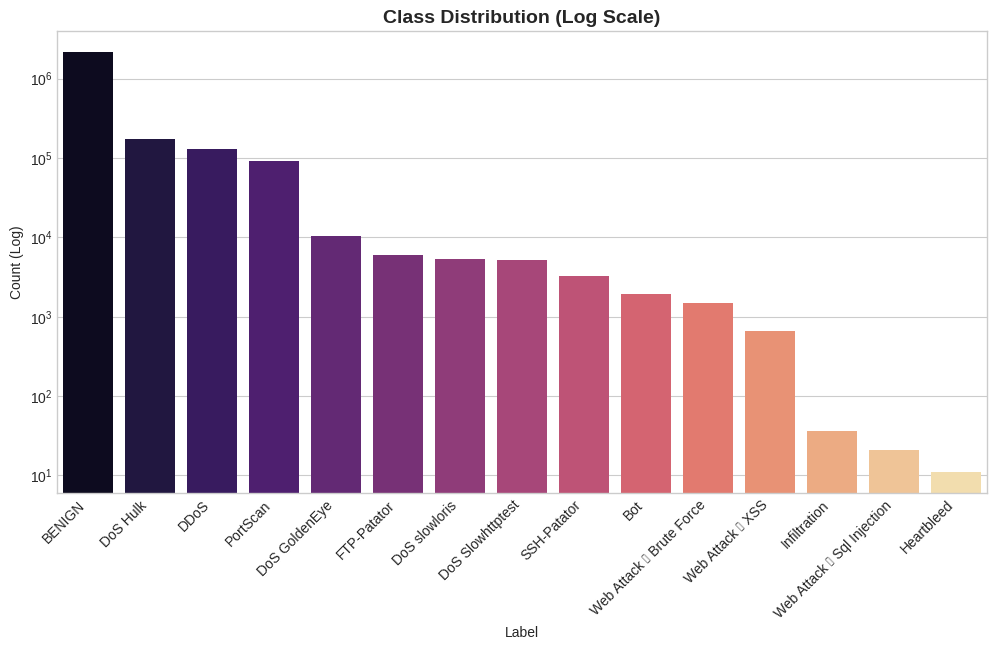

Percentage of Benign Traffic: 83.46%


In [3]:
# --- 3. TARGET DISTRIBUTION ---
plt.figure(figsize=(12, 6))
label_counts = df['Label'].value_counts()

sns.barplot(x=label_counts.index, y=label_counts.values, palette='magma', hue=label_counts.index, legend=False)
plt.yscale('log')
plt.title("Class Distribution (Log Scale)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count (Log)")
plt.show()

print("Percentage of Benign Traffic: {:.2f}%".format((label_counts['BENIGN'] / len(df)) * 100))

4. Feature Distribution & Skewness

Dropped 8 zero-variance columns.


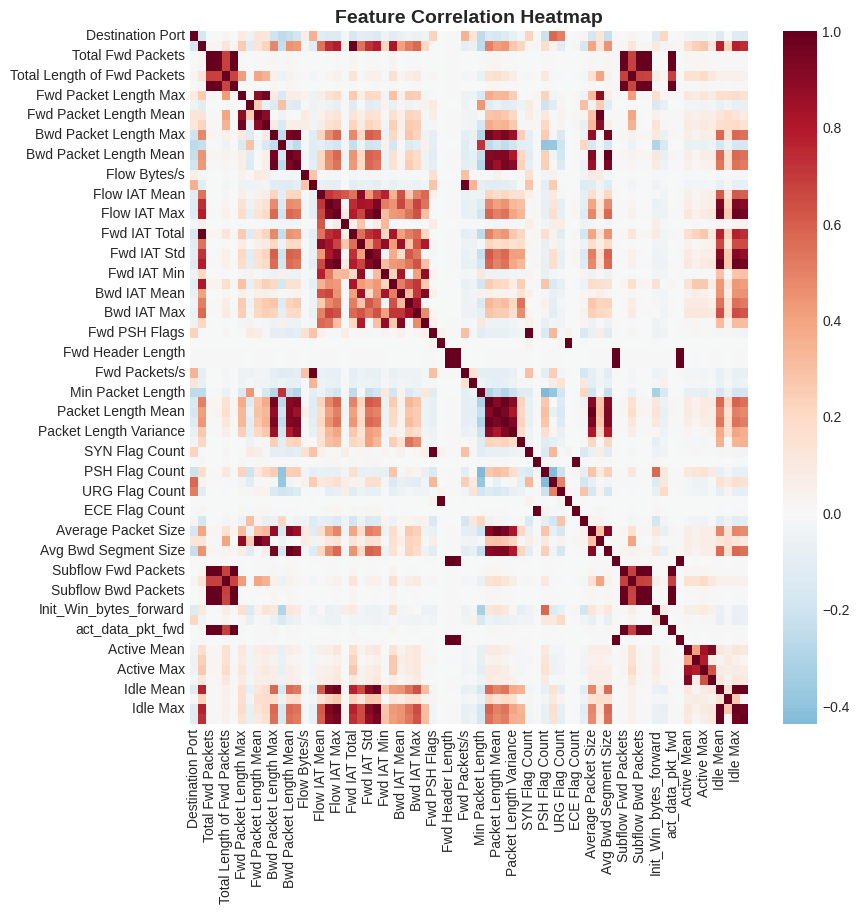

Identified 27 redundant features for potential removal.


In [12]:
# --- 4. FEATURE SELECTION: VARIANCE & CORRELATION ---
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)
print(f"Dropped {len(constant_cols)} zero-variance columns.")

plt.figure(figsize=(9, 9))
sample_corr = df.sample(100000).corr(numeric_only=True)

sns.heatmap(sample_corr, cmap='RdBu_r', center=0, annot=False)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.show()

upper = sample_corr.abs().where(np.triu(np.ones(sample_corr.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
print(f"Identified {len(to_drop)} redundant features for potential removal.")

5. Correlation & Hierarchical Mapping

/tmp/ipykernel_4624/2447896468.py:11: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


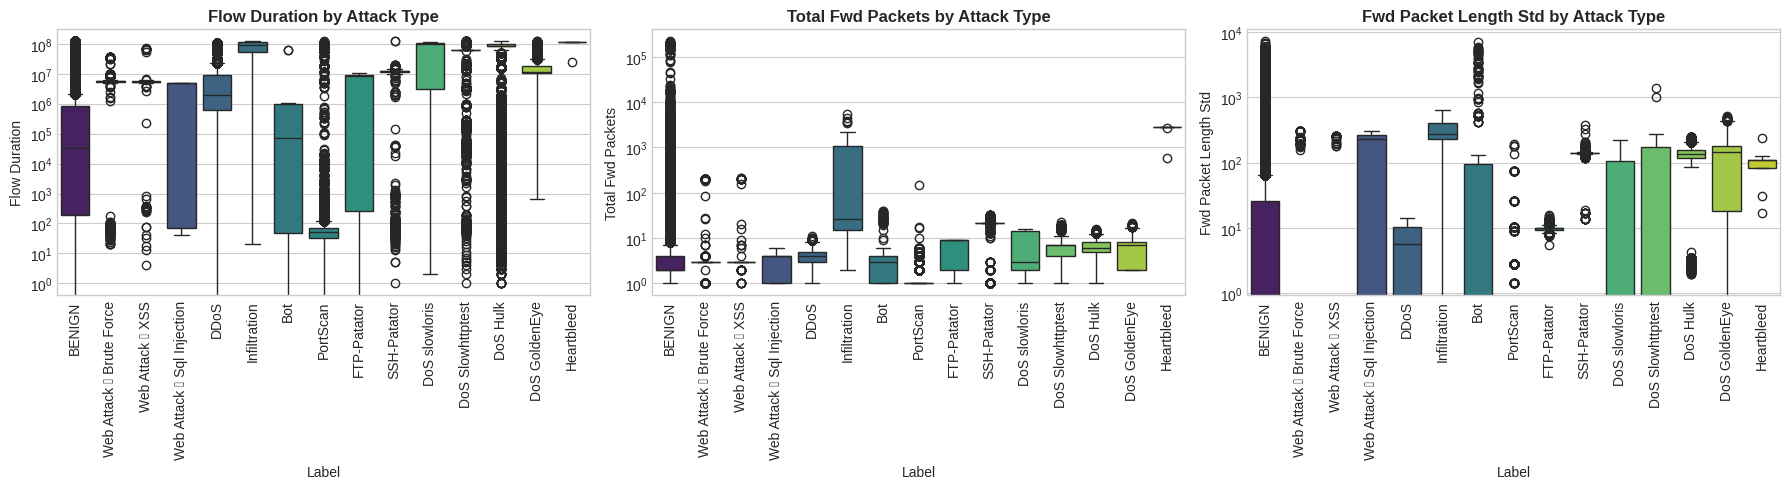

In [5]:
# --- 5. ATTACK ANALYSIS ---
key_metrics = ['Flow Duration', 'Total Fwd Packets', 'Fwd Packet Length Std']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(key_metrics):
    sns.boxplot(data=df, x='Label', y=col, ax=axes[i], palette='viridis', hue='Label', legend=False)
    axes[i].set_yscale('log')
    axes[i].set_title(f"{col} by Attack Type", fontweight='bold')
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

6. Feature Importance & Outliers

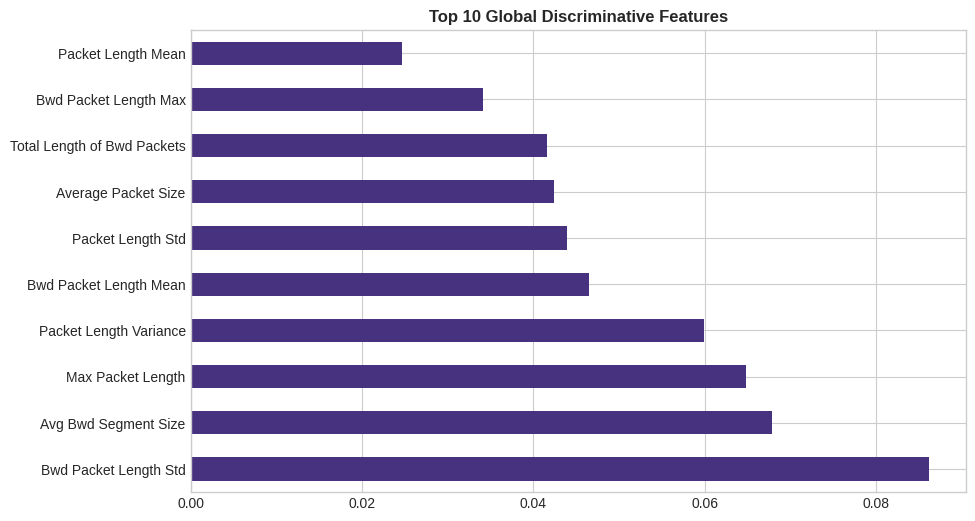

In [14]:
# --- 6. IMPORTANCE & OUTLIERS ---
rf_sample = df.sample(100000)
X_rf = rf_sample.drop('Label', axis=1).fillna(0)
y_rf = np.where(rf_sample['Label'] == 'BENIGN', 0, 1)

rf = RandomForestClassifier(n_estimators=50, max_depth=8, n_jobs=-1)
rf.fit(X_rf, y_rf)

plt.figure(figsize=(10, 6))
pd.Series(rf.feature_importances_, index=X_rf.columns).nlargest(10).plot(kind='barh')
plt.title("Top 10 Global Discriminative Features", fontweight='bold')
plt.show()

7. Dimensionality Reduction (PCA)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


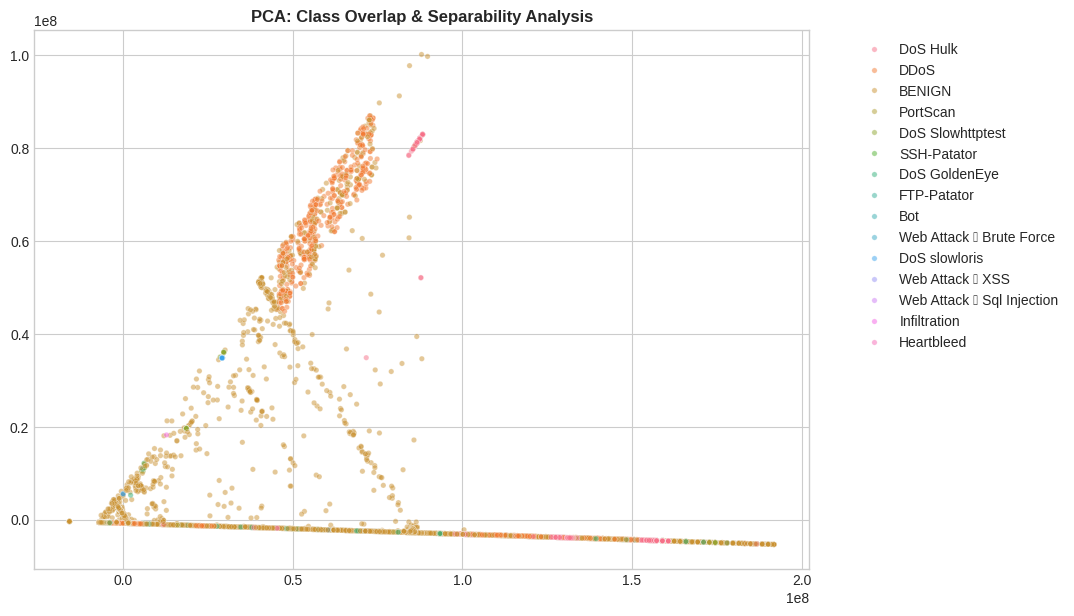

In [15]:
# --- 7. PCA PROJECTION ---
pca_sample = df.sample(100000)
scaler_pca = RobustScaler()
X_pca_std = scaler_pca.fit_transform(pca_sample.drop('Label', axis=1))

pca = PCA(n_components=2)
coords = pca.fit_transform(X_pca_std)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=pca_sample['Label'], alpha=0.5, s=15)
plt.title("PCA: Class Overlap & Separability Analysis", fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()